In [85]:
import pandas as pd
import numpy as np
import os
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense
import kagglehub


In [86]:
dir_path = kagglehub.dataset_download("arashnic/cinema-ticket")
csv_filename = 'cinemaTicket_Ref.csv'
full_file_path = os.path.join(dir_path, csv_filename)
df = pd.read_csv(full_file_path)
df
#по врианту наша целевая - capacity

,film_code,cinema_code,total_sales,tickets_sold,tickets_out,show_time,occu_perc,ticket_price,ticket_use,capacity,date,month,quarter,day
0,1492,304,3900000,26,0,4,4.26,150000.0,26,610.328638,2018-05-05,5,2,5
1,1492,352,3360000,42,0,5,8.08,80000.0,42,519.801980,2018-05-05,5,2,5
2,1492,489,2560000,32,0,4,20.00,80000.0,32,160.000000,2018-05-05,5,2,5
3,1492,429,1200000,12,0,1,11.01,100000.0,12,108.991826,2018-05-05,5,2,5
4,1492,524,1200000,15,0,3,16.67,80000.0,15,89.982004,2018-05-05,5,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142519,1569,495,1320000,22,0,2,3.86,60000.0,22,569.948187,2018-11-04,11,4,4
142520,1569,474,1200000,15,0,1,65.22,80000.0,15,22.999080,2018-11-04,11,4,4
142521,1569,524,1060000,8,0,3,9.20,132500.0,8,86.956522,2018-11-04,11,4,4
142522,1569,529,600000,5,0,2,5.00,120000.0,5,100.000000,2018-11-04,11,4,4


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142524 entries, 0 to 142523
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   film_code     142524 non-null  int64  
 1   cinema_code   142524 non-null  int64  
 2   total_sales   142524 non-null  int64  
 3   tickets_sold  142524 non-null  int64  
 4   tickets_out   142524 non-null  int64  
 5   show_time     142524 non-null  int64  
 6   occu_perc     142399 non-null  float64
 7   ticket_price  142524 non-null  float64
 8   ticket_use    142524 non-null  int64  
 9   capacity      142399 non-null  float64
 10  date          142524 non-null  object 
 11  month         142524 non-null  int64  
 12  quarter       142524 non-null  int64  
 13  day           142524 non-null  int64  
dtypes: float64(3), int64(10), object(1)
memory usage: 15.2+ MB


- Из того,что надо фиксить - перевести *date* из object в datetime
- Также можем наблюдать, что есть пропуски, лучше детальнее посмотреть в каких именно колонках и сколько

In [88]:
df.isna().sum()

film_code         0
cinema_code       0
total_sales       0
tickets_sold      0
tickets_out       0
show_time         0
occu_perc       125
ticket_price      0
ticket_use        0
capacity        125
date              0
month             0
quarter           0
day               0
dtype: int64

- *occu_perc* и, к сожалению наша целевая переменная *capacity* содержат пропуски (по 125 значений)

In [89]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
df_imputed = imputer.fit_transform(df[['occu_perc', 'capacity']])
df_imputed = pd.DataFrame(df_imputed, columns=['occu_perc', 'capacity'])
df.loc[:, 'occu_perc'] = df_imputed.loc[:, 'occu_perc']
df.loc[:, 'capacity'] = df_imputed.loc[:, 'capacity']
df.isna().sum()

film_code       0
cinema_code     0
total_sales     0
tickets_sold    0
tickets_out     0
show_time       0
occu_perc       0
ticket_price    0
ticket_use      0
capacity        0
date            0
month           0
quarter         0
day             0
dtype: int64

- Воспользовались SimpleImputer и заполнили пропуски средним значением по признаку (ввиду того что у нас всего 125 пропусков на 124000 объектов можно было конечно их просто дропнуть но мне почему-то захотелось их заполнить)

In [90]:
df.loc[:,'date'] = pd.to_datetime(df.loc[:,'date'], format='%Y-%m-%d')
df = df.sort_values(by='date')
df

,film_code,cinema_code,total_sales,tickets_sold,tickets_out,show_time,occu_perc,ticket_price,ticket_use,capacity,date,month,quarter,day
46143,1471,448,32030000,267,0,2,47.76,119962.546816,267,559.045226,2018-02-21 00:00:00,2,1,21
46142,1471,518,180000,3,0,1,2.07,60000.000000,3,144.927536,2018-02-23 00:00:00,2,1,23
104016,1485,304,43200000,363,0,8,21.42,119008.264463,363,1694.677871,2018-03-14 00:00:00,3,1,14
72077,1483,83,300000,3,0,10,0.21,100000.000000,3,1428.571429,2018-03-14 00:00:00,3,1,14
72076,1483,262,560000,7,0,3,0.73,80000.000000,7,958.904110,2018-03-14 00:00:00,3,1,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51977,1587,164,770000,11,0,4,6.25,70000.000000,11,176.000000,2018-11-04 00:00:00,11,4,4
51976,1587,181,1040000,13,0,4,2.17,80000.000000,13,599.078341,2018-11-04 00:00:00,11,4,4
51975,1587,160,1520000,19,0,3,0.94,80000.000000,19,2021.276596,2018-11-04 00:00:00,11,4,4
51973,1587,474,3880000,43,0,2,68.25,90232.558140,43,63.003663,2018-11-04 00:00:00,11,4,4


- Тут мы перевели признак *date* в тип datetime и отсортироавали датасет по датам

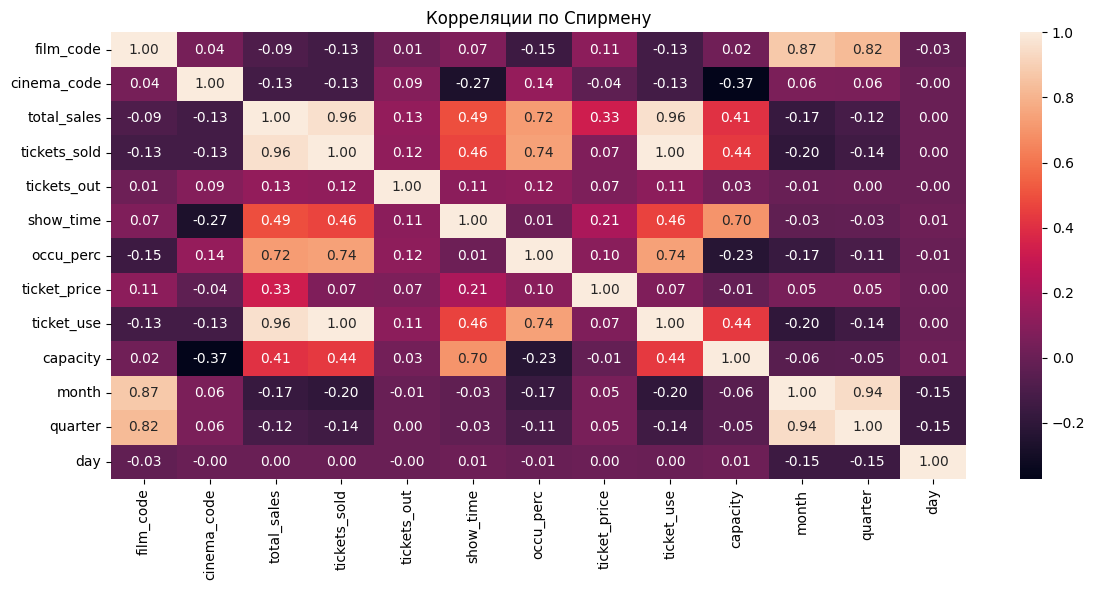

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
corr = df.corr(method='spearman', numeric_only=True)
plt.figure(figsize=(12, 6))
sns.heatmap(corr, fmt='.2f', annot=True)
plt.title('Корреляции по Спирмену')
plt.tight_layout()
plt.show()

- Первое, что мы можем заметить, это мультиколлинеарности, от которых надо будет избавляться
- Далее мы видим, что с целевой переменной есть сильная пололжительная корреляция у *total_sales*, *tickets_sold* и *ticket_use*, что в целом очевидно, так как они и зависят от вместительности. Что менее очевидно, так это корреляция с *show_time*, хотя на самом деле объясняется это тем, что от вместительности зависит общее время показа
- Есть и сильные отрицательные корреляции с *cinema_code* и *occu_perc*, что пока что не имеет никакого объяснения

In [92]:
df.duplicated().sum()

np.int64(106)

- У нас 106 полностью одинаковых строк, что не очень то и хорошо, поэтому их мы дропаем

In [93]:
df = df.drop_duplicates()

In [94]:
df.nunique()

film_code          48
cinema_code       246
total_sales      9464
tickets_sold     2231
tickets_out        96
show_time          51
occu_perc        9312
ticket_price    23235
ticket_use       2283
capacity        57362
date              234
month              10
quarter             4
day                31
dtype: int64

- Судя по всему данные не кажутся разреженными, и это довольно таки хорошо, очень сильно упрощает жизнь

c:\study\OOD\OOD\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


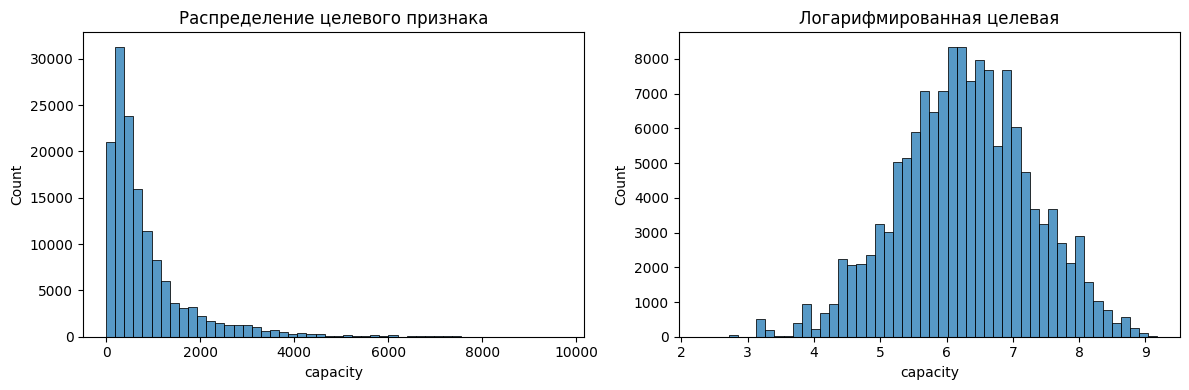

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['capacity'], bins=50, ax=axes[0])
axes[0].set_title('Распределение целевого признака')

sns.histplot(np.log(df['capacity']), bins=50, ax=axes[1])
axes[1].set_title('Логарифмированная целевая')
plt.tight_layout()
plt.show()

- Распределение целевого признака сильно скожено, поэтому попробуем логарифмировать всё это дело. В любом случае уже видно, что в основном вместимость не превышает 4000 человек
- Логарфимировав дела стале намного лучше, мы получили практически нормально распределённый целевой признак

In [96]:
df.loc[:,'capacity_log'] = np.log1p(df.loc[:,'capacity'])
df

c:\study\OOD\OOD\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\dybal\AppData\Local\Temp\ipykernel_17200\3373160474.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,'capacity_log'] = np.log1p(df.loc[:,'capacity'])


,film_code,cinema_code,total_sales,tickets_sold,tickets_out,show_time,occu_perc,ticket_price,ticket_use,capacity,date,month,quarter,day,capacity_log
46143,1471,448,32030000,267,0,2,47.76,119962.546816,267,559.045226,2018-02-21 00:00:00,2,1,21,6.328018
46142,1471,518,180000,3,0,1,2.07,60000.000000,3,144.927536,2018-02-23 00:00:00,2,1,23,4.983110
104016,1485,304,43200000,363,0,8,21.42,119008.264463,363,1694.677871,2018-03-14 00:00:00,3,1,14,7.435838
72077,1483,83,300000,3,0,10,0.21,100000.000000,3,1428.571429,2018-03-14 00:00:00,3,1,14,7.265130
72076,1483,262,560000,7,0,3,0.73,80000.000000,7,958.904110,2018-03-14 00:00:00,3,1,14,6.866833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51977,1587,164,770000,11,0,4,6.25,70000.000000,11,176.000000,2018-11-04 00:00:00,11,4,4,5.176150
51976,1587,181,1040000,13,0,4,2.17,80000.000000,13,599.078341,2018-11-04 00:00:00,11,4,4,6.397060
51975,1587,160,1520000,19,0,3,0.94,80000.000000,19,2021.276596,2018-11-04 00:00:00,11,4,4,7.611979
51973,1587,474,3880000,43,0,2,68.25,90232.558140,43,63.003663,2018-11-04 00:00:00,11,4,4,4.158940


- На основе имеющегося целевого признака создаём новый логарифмированный и старый можем дропнуть

In [97]:
candidates_features = ['total_sales', 'tickets_sold', 'ticket_use', 'show_time', 'cinema_code', 'occu_perc', 'date', 'month', 'quarter', 'day', 'capacity_log']
feature_to_drop = [feature for feature in df.columns if feature not in candidates_features]
df = df.drop(feature_to_drop, axis=1)
df

,cinema_code,total_sales,tickets_sold,show_time,occu_perc,ticket_use,date,month,quarter,day,capacity_log
46143,448,32030000,267,2,47.76,267,2018-02-21 00:00:00,2,1,21,6.328018
46142,518,180000,3,1,2.07,3,2018-02-23 00:00:00,2,1,23,4.983110
104016,304,43200000,363,8,21.42,363,2018-03-14 00:00:00,3,1,14,7.435838
72077,83,300000,3,10,0.21,3,2018-03-14 00:00:00,3,1,14,7.265130
72076,262,560000,7,3,0.73,7,2018-03-14 00:00:00,3,1,14,6.866833
...,...,...,...,...,...,...,...,...,...,...,...
51977,164,770000,11,4,6.25,11,2018-11-04 00:00:00,11,4,4,5.176150
51976,181,1040000,13,4,2.17,13,2018-11-04 00:00:00,11,4,4,6.397060
51975,160,1520000,19,3,0.94,19,2018-11-04 00:00:00,11,4,4,7.611979
51973,474,3880000,43,2,68.25,43,2018-11-04 00:00:00,11,4,4,4.158940


- На этом этапе я решил дропнуть некоторые из фичей (которые посчитал ненужными) дабы не забыть и было проще ориентироваться в данных

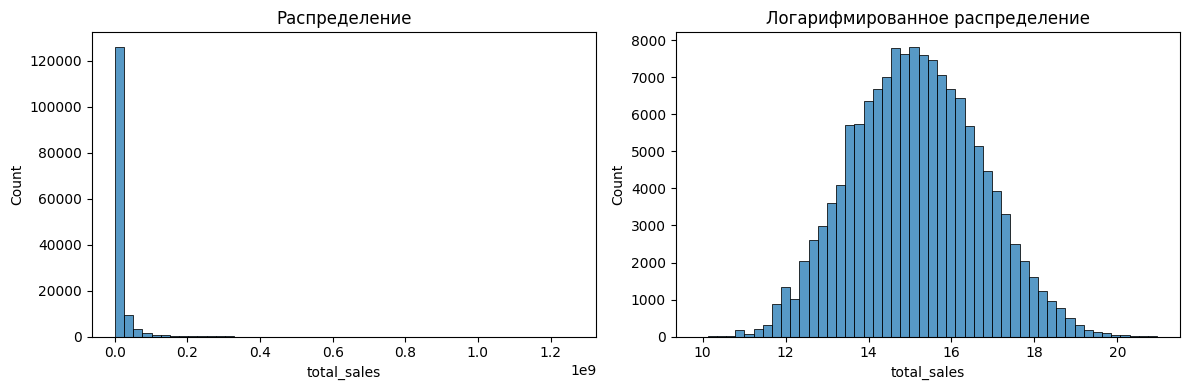

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['total_sales'], bins=50, ax=axes[0])
axes[0].set_title('Распределение')

sns.histplot(np.log(df['total_sales']), bins=50, ax=axes[1])
axes[1].set_title('Логарифмированное распределение')
plt.tight_layout()
plt.show()

- Опять же видим что признак очень сильно скошен, поэтому логарифмируем
- Логарифимровав получаем практически идеально нормально распределённый признак, поэтому можем заменить его на логарифм

In [99]:
df.loc[:,'total_sales_log'] = np.log1p(df.loc[:, 'total_sales'])
df = df.drop(['total_sales'], axis=1)

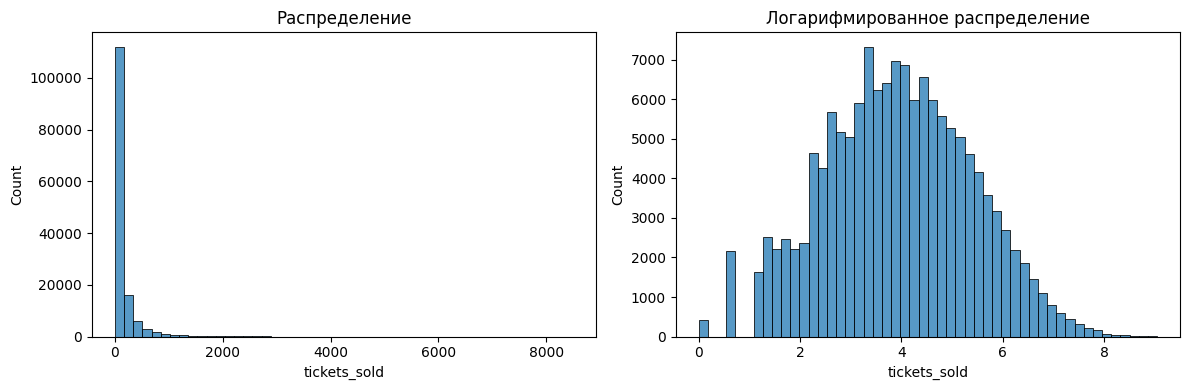

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['tickets_sold'], bins=50, ax=axes[0])
axes[0].set_title('Распределение')

sns.histplot(np.log(df['tickets_sold']), bins=50, ax=axes[1])
axes[1].set_title('Логарифмированное распределение')
plt.tight_layout()
plt.show()

- Уже знакомая картина, поэтому делаем всё то же самое

In [101]:
df.loc[:, 'tickets_sold_log'] = np.log1p(df.loc[:, 'tickets_sold'])
df = df.drop(['tickets_sold'], axis=1)

c:\study\OOD\OOD\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


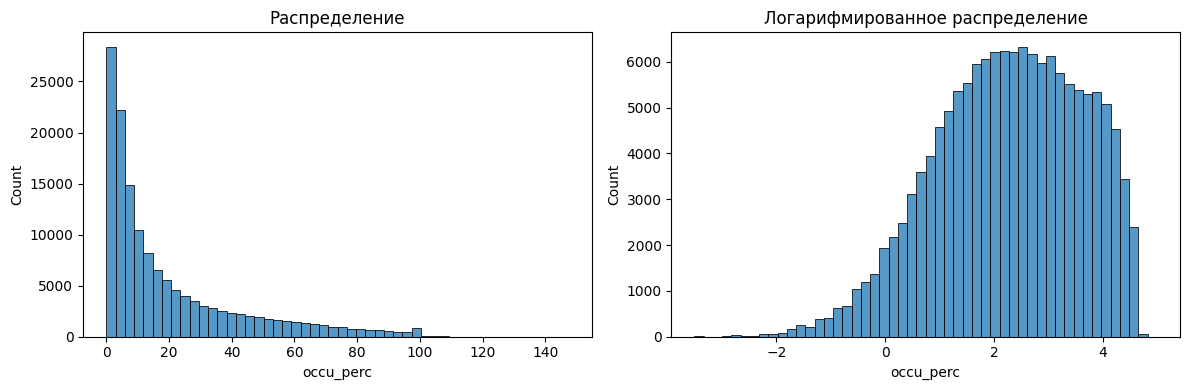

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['occu_perc'], bins=50, ax=axes[0])
axes[0].set_title('Распределение')

sns.histplot(np.log(df['occu_perc']), bins=50, ax=axes[1])
axes[1].set_title('Логарифмированное распределение')
plt.tight_layout()
plt.show()

In [103]:
df.loc[:, 'occu_perc_log'] = np.log1p(df.loc[:, 'occu_perc'])
df = df.drop(['occu_perc'], axis=1)

c:\study\OOD\OOD\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\study\OOD\OOD\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


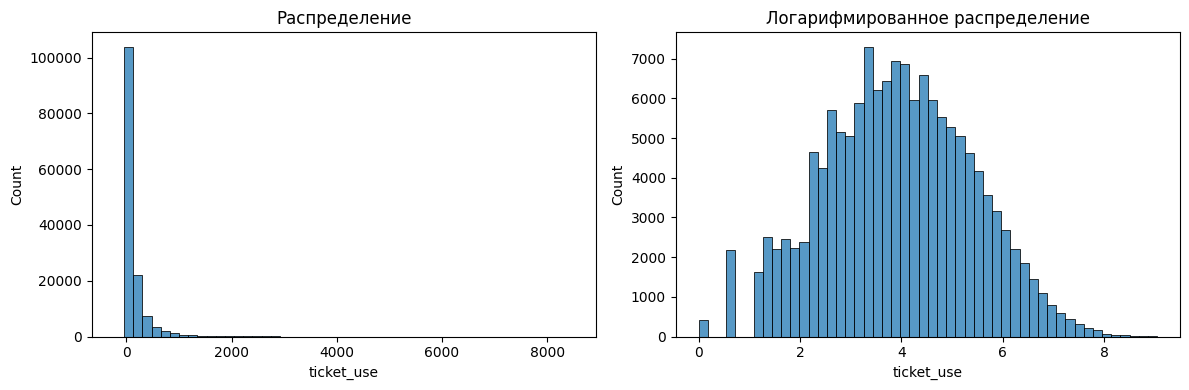

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['ticket_use'], bins=50, ax=axes[0])
axes[0].set_title('Распределение')

sns.histplot(np.log(df['ticket_use']), bins=50, ax=axes[1])
axes[1].set_title('Логарифмированное распределение')
plt.tight_layout()
plt.show()

- Интерпретатор ругается на деление на ноль, поэтому сделаем то что я забыл сделать - посмотрим на статистические свойства данных

In [105]:
df.describe()

,cinema_code,show_time,ticket_use,month,quarter,day,capacity_log,total_sales_log,tickets_sold_log,occu_perc_log
count,142418.000000,142418.000000,142418.000000,142418.000000,142418.000000,142418.000000,142364.000000,142418.000000,142418.000000,142418.000000
mean,320.388806,3.931610,139.810733,6.779663,2.635938,16.106714,6.275612,15.150432,3.980161,2.459816
std,159.703461,3.056189,279.531300,2.194240,0.808764,8.950213,0.999816,1.544028,1.394786,1.126845
min,32.000000,1.000000,-219.000000,2.000000,1.000000,1.000000,2.397895,9.903538,0.693147,0.000000
25%,181.000000,2.000000,18.000000,5.000000,2.000000,8.000000,5.635966,14.046623,2.944439,1.558145
50%,324.000000,3.000000,50.000000,7.000000,3.000000,16.000000,6.267800,15.126543,3.931826,2.430098
75%,474.000000,5.000000,143.000000,9.000000,3.000000,24.000000,6.946256,16.222456,4.969813,3.373484
max,637.000000,60.000000,8499.000000,11.000000,4.000000,31.000000,9.179169,20.956613,9.047821,5.000585


- *ticket_use* имеет отрицательные значения, а такого быть априори не может, надо исправлять

In [106]:
df = df[df['ticket_use'] >=0]
df.describe()

,cinema_code,show_time,ticket_use,month,quarter,day,capacity_log,total_sales_log,tickets_sold_log,occu_perc_log
count,142357.000000,142357.000000,142357.000000,142357.000000,142357.000000,142357.000000,142303.000000,142357.000000,142357.000000,142357.000000
mean,320.377150,3.931637,139.886827,6.779681,2.635972,16.106402,6.275657,15.151155,3.980830,2.460329
std,159.701853,3.056410,279.564817,2.194352,0.808783,8.950217,0.999888,1.543738,1.394512,1.126640
min,32.000000,1.000000,0.000000,2.000000,1.000000,1.000000,2.397895,9.903538,0.693147,0.000000
25%,181.000000,2.000000,18.000000,5.000000,2.000000,8.000000,5.635966,14.046623,2.944439,1.560248
50%,324.000000,3.000000,50.000000,7.000000,3.000000,16.000000,6.267800,15.129234,3.931826,2.430978
75%,474.000000,5.000000,143.000000,9.000000,3.000000,24.000000,6.946331,16.222456,4.969813,3.373826
max,637.000000,60.000000,8499.000000,11.000000,4.000000,31.000000,9.179169,20.956613,9.047821,5.000585


In [107]:
df.loc[:, 'ticket_use_log'] = np.log1p(df.loc[:, 'ticket_use'])
df = df.drop(['ticket_use'], axis=1)


- На данном этапе, можем посмотреть есть ли какая нибудь зависимость от месяца или дня

In [108]:
monthly_capacity = df.groupby(['month']).agg({
    'capacity_log' : 'mean'
}).reset_index()

daily_capacity = df.groupby(['day']).agg({
    'capacity_log' : 'mean'
}).reset_index()

quarter_capacity = df.groupby(['quarter']).agg({
    'capacity_log' : 'mean'
}).reset_index()

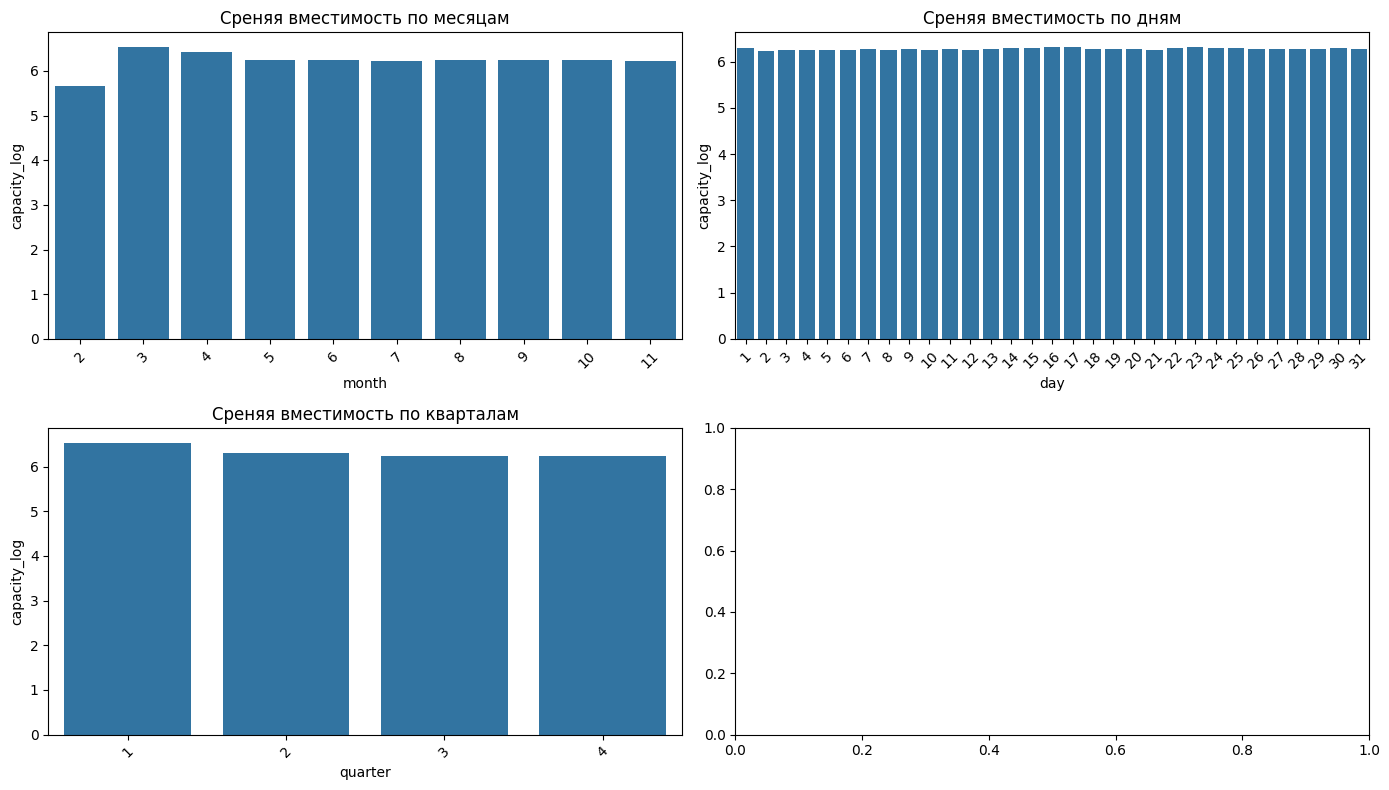

In [109]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.barplot(x=monthly_capacity['month'], y=monthly_capacity['capacity_log'], ax=axes[0,0])
axes[0,0].tick_params('x', rotation=45)
axes[0,0].set_title('Среняя вместимость по месяцам')

sns.barplot(x=daily_capacity['day'], y=daily_capacity['capacity_log'], ax=axes[0,1])
axes[0,1].tick_params('x', rotation=45)
axes[0,1].set_title('Среняя вместимость по дням')

sns.barplot(x=quarter_capacity['quarter'], y=quarter_capacity['capacity_log'], ax=axes[1,0])
axes[1,0].set_title('Среняя вместимость по кварталам')
axes[1,0].tick_params('x', rotation=45)

plt.tight_layout()
plt.show()

- Тут всё очень даже хорошо и данные распределены равномерно, подозреваю даже, что не будет никакой сезонности
- Поскольку для модели эти признаки никакой новой информации давать не будут, их мы можем просто дропнуть

In [110]:
df = df.drop(['month', 'day', 'quarter'], axis=1)

In [111]:
df = df.drop(['cinema_code'], axis=1)

- Ввиду странной корреляции с *cinema_code*, я приняло волевое решение этот признак дропнуть

In [112]:
df

,show_time,date,capacity_log,total_sales_log,tickets_sold_log,occu_perc_log,ticket_use_log
46143,2,2018-02-21 00:00:00,6.328018,17.282184,5.590987,3.886910,5.590987
46142,1,2018-02-23 00:00:00,4.983110,12.100718,1.386294,1.121678,1.386294
104016,8,2018-03-14 00:00:00,7.435838,17.581351,5.897154,3.109953,5.897154
72077,10,2018-03-14 00:00:00,7.265130,12.611541,1.386294,0.190620,1.386294
72076,3,2018-03-14 00:00:00,6.866833,13.235694,2.079442,0.548121,2.079442
...,...,...,...,...,...,...,...
51977,4,2018-11-04 00:00:00,5.176150,13.554147,2.484907,1.981001,2.484907
51976,4,2018-11-04 00:00:00,6.397060,13.854732,2.639057,1.153732,2.639057
51975,3,2018-11-04 00:00:00,7.611979,14.234222,2.995732,0.662688,2.995732
51973,2,2018-11-04 00:00:00,4.158940,15.171346,3.784190,4.237723,3.784190


In [113]:
df_aggregated = df.groupby(['date']).agg({
    'show_time':'mean',
    'capacity_log':'mean',
    'total_sales_log':'mean',
    'tickets_sold_log':'mean',
    'occu_perc_log':'mean',
    'ticket_use_log':'mean'
}).reset_index()
df_aggregated

,date,show_time,capacity_log,total_sales_log,tickets_sold_log,occu_perc_log,ticket_use_log
0,2018-02-21,2.000000,6.328018,17.282184,5.590987,3.886910,5.590987
1,2018-02-23,1.000000,4.983110,12.100718,1.386294,1.121678,1.386294
2,2018-03-14,6.131250,6.832370,15.474839,3.995557,2.010891,3.990653
3,2018-03-15,5.649351,6.740475,15.758022,4.307722,2.350839,4.305411
4,2018-03-16,5.274576,6.688472,15.731139,4.364895,2.433547,4.361631
...,...,...,...,...,...,...,...
229,2018-10-31,3.789630,6.262580,14.948584,3.667317,2.208980,3.663984
230,2018-11-01,3.750704,6.224506,15.388443,4.068470,2.585696,4.065043
231,2018-11-02,3.757310,6.220422,15.502162,4.162337,2.659380,4.160780
232,2018-11-03,3.819237,6.232921,14.573058,3.555261,2.112519,3.552527


- После аггрегирования получилось всего 234 объекта... Это ничтожно мало, но будем пробовать как-то крутиться

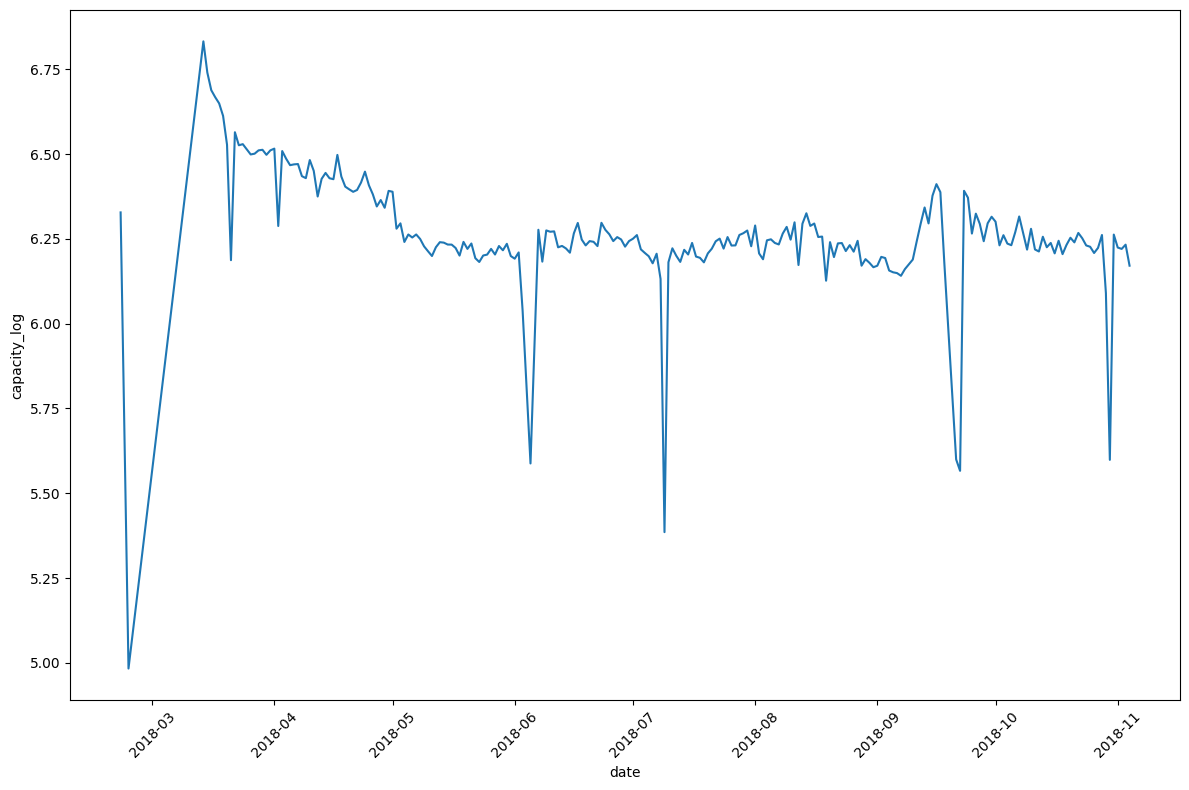

In [114]:
plt.figure(figsize=(12, 8))
sns.lineplot(x=df_aggregated['date'], y=df_aggregated['capacity_log'])
plt.tick_params('x', rotation=45)
plt.tight_layout()
plt.show()

In [115]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

adf = adfuller(df_aggregated['capacity_log'])
print(f'p-value = {adf[1]}')

p-value = 0.004519111930069282


- Таким образом мы отклоняем гипотезу о нулевом корне, вследствие чего ряд стационарен, но всё же стоит взглянуть на автокорреляционные функции

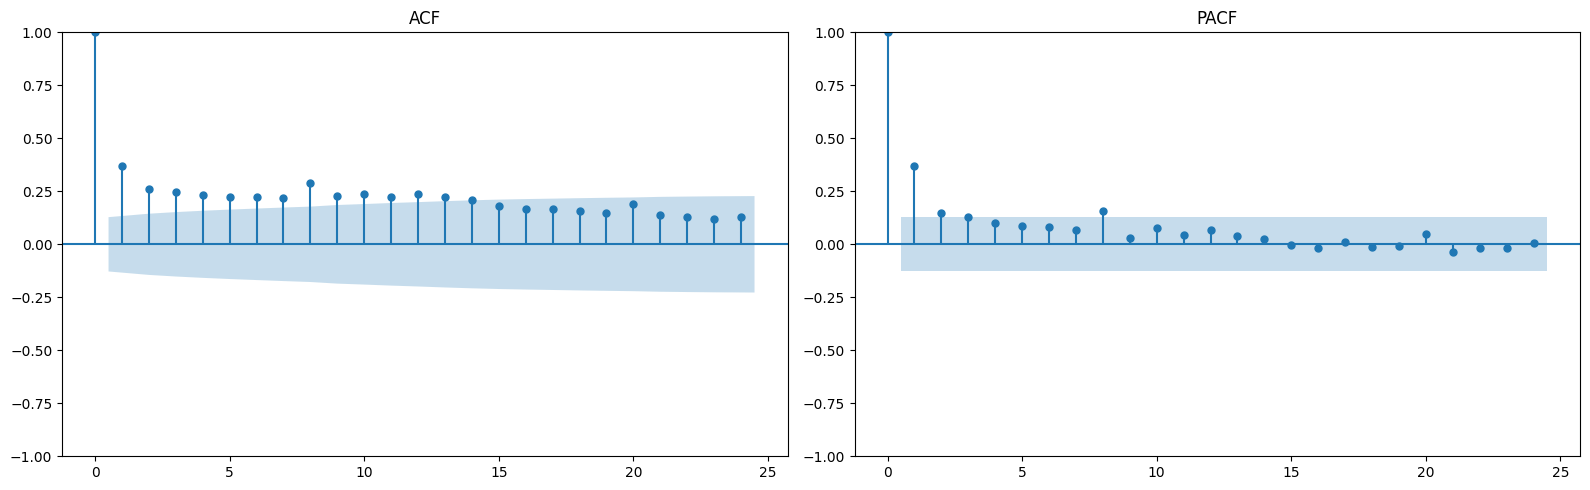

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(df_aggregated['capacity_log'], ax=axes[0])
axes[0].set_title('ACF')

plot_pacf(df_aggregated['capacity_log'], ax=axes[1])
axes[1].set_title('PACF')

plt.tight_layout()
plt.show()

In [117]:
from statsmodels.tsa.arima.model import ARIMA
df_aggregated = df_aggregated.set_index('date')
model = ARIMA(endog=df_aggregated['capacity_log'],exog=df_aggregated.drop(['capacity_log'],axis=1), order=(1,0,0))
res=model.fit()

c:\study\OOD\OOD\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\study\OOD\OOD\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\study\OOD\OOD\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [118]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           capacity_log   No. Observations:                  234
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 498.638
Date:                Fri, 05 Sep 2025   AIC                           -981.277
Time:                        23:10:08   BIC                           -953.634
Sample:                             0   HQIC                          -970.131
                                - 234                                         
Covariance Type:                  opg                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                5.2250      0.084     61.988      0.000       5.060       5.390
show_time            0.0372      0.004     10.332      0.000       0.030       0.044
total_sales_log     -0.0261      0.008     -3.266      0.001      -0.042      -0.010
tickets_sold_log     2.7293      0.902      3.026      0.002       0.961       4.497
occu_perc_log       -1.0910      0.011    -95.481      0.000      -1.113      -1.069
ticket_use_log      -1.7295      0.899     -1.924      0.054      -3.492       0.033
ar.L1                0.2433      0.054      4.514      0.000       0.138       0.349
sigma2               0.0008   4.62e-05     17.781      0.000       0.001       0.001
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              1636.91
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               0.81   Skew:                             1.71
Prob(H) (two-sided):                  0.37   Kurtosis:                        15.50
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [119]:
forecast = res.forecast(steps=10, exog=df_aggregated.drop(['capacity_log'],axis=1)[:10])
np.expm1(forecast)

c:\study\OOD\OOD\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\study\OOD\OOD\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


234    489.653094
235    164.425386
236    951.723107
237    871.055937
238    832.973062
239    801.326505
240    782.133538
241    734.241711
242    575.886203
243    472.478183
Name: predicted_mean, dtype: float64

In [129]:
data = df_aggregated.values
target_col_index = 1
n_steps = 30 
X, y = [], []

for i in range(len(data)):
    end_ix = i + n_steps
    if end_ix > len(data)-1:
        break
    seq_x = data[i:end_ix, :] 
    seq_y = data[end_ix, target_col_index] 
    
    X.append(seq_x)
    y.append(seq_y)
X = np.array(X)
y = np.array(y)

In [130]:
split_percentage = 0.8
split_index = int(len(X) * split_percentage)

X_train = X[:split_index]
y_train = y[:split_index]

X_test = X[split_index:]
y_test = y[split_index:]

In [148]:
from keras.regularizers import l2
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]
model = Sequential()
model.add(LSTM(units=8, return_sequences=True, input_shape=(n_timesteps, n_features)))
model.add(Dropout(0.2))
model.add(LSTM(units=16, return_sequences=True, input_shape=(n_timesteps, n_features))) 
model.add(Dropout(0.2))
model.add(LSTM(units=16))
model.add(Dense(units=1, kernel_regularizer=l2))
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


c:\study\OOD\OOD\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_17 (LSTM)                  │ (None, 30, 8)          │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 30, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 30, 16)         │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 30, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,209 (16.44 KB)

 Trainable params: 4,209 (16.44 KB)

 Non-trainable params: 0 (0.00 B)

In [149]:
model.fit(X_train, y_train, batch_size=8, epochs=25)

Epoch 1/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 38.7944
Epoch 2/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 25.2509
Epoch 3/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 13.4528
Epoch 4/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.0766
Epoch 5/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.9537
Epoch 6/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6031
Epoch 7/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.8680
Epoch 8/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4573
Epoch 9/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2392
Epoch 10/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1409
Epoch 11/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0975
Epoch 12/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0701
Epoch 13/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0599
Epoch 14/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0567
Epoch 15/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0533
E

In [150]:
model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0438 


0.04377978667616844

In [151]:
from sklearn.metrics import root_mean_squared_error
preds = model.predict(X_test).flatten()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step


In [152]:
print(f'RMSE: {root_mean_squared_error(np.expm1(y_test), np.expm1(preds))}')

RMSE: 44.20067680724351
